In [22]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # hide GPUs
# os.environ["JAX_PLATFORM_NAME"] = "cpu"  # force CPU backend in this notebook

In [23]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import jax
from netket.operator.fermion import create as cdag
from netket.operator.fermion import destroy as c
from netket.operator.fermion import number as nc

In [24]:
#single particle parameters

t1 = 1.0
t2 = -1/(4 * np.cos(0.65)) #-1/(4 * np.cos(0.65)) #0.15
phi = 0.65 #np.pi / 2
m = 0.

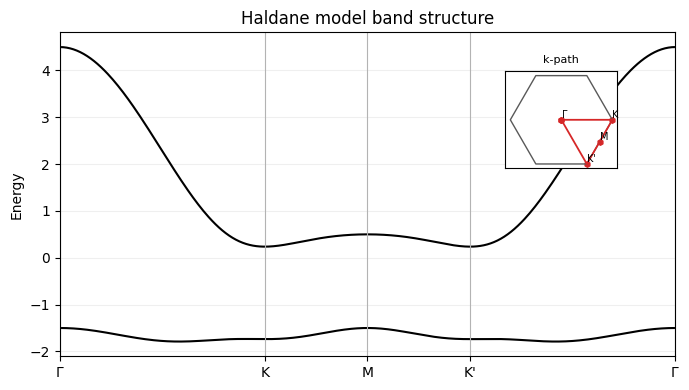

K point used = [4.18879020, 0.00000000]
Berry curvature at K (lower band): 0.38452690
Trace of quantum metric at K (lower band): 0.38452690
Estimated Chern number (lower band) = 1.0000000000
Estimated quantum weight (lower band) = 1.0664954341


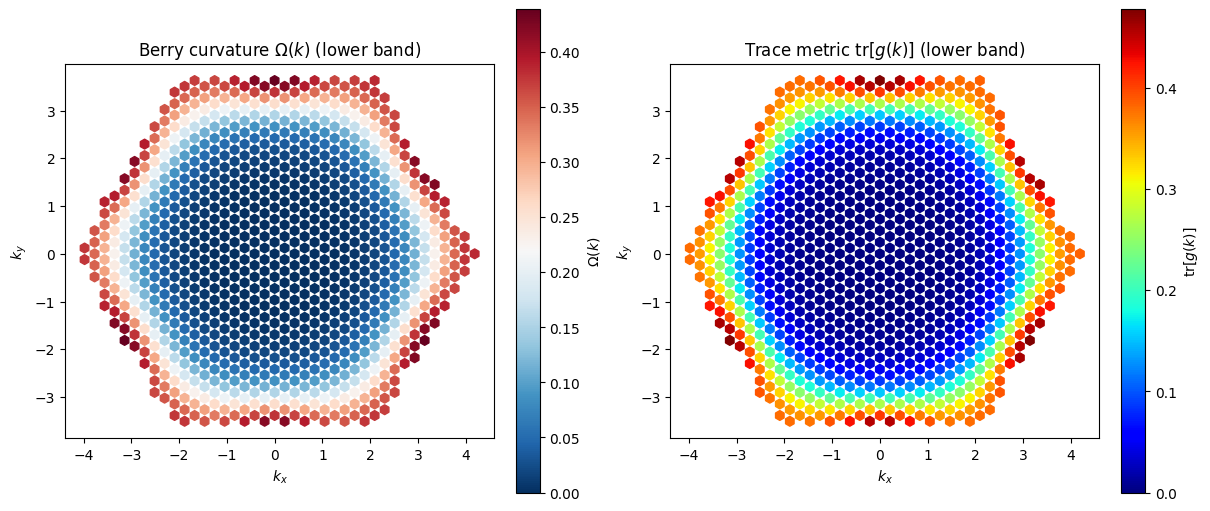

In [25]:
#single particle properties

import matplotlib.pyplot as plt
# Bravais vectors used by nk.graph.Honeycomb in this NetKet version
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3.0) / 2.0])
# Sublattice offsets used by Honeycomb; from these we build NN vectors A -> B
rA = np.array([0.5, 0.5 / np.sqrt(3.0)])
rB = np.array([1.0, 1.0 / np.sqrt(3.0)])
# Nearest-neighbor vectors and oriented NNN vectors (all geometry from one convention)
delta_vectors = (rB - rA, rB - rA - a1, rB - rA - a2)
annn_vectors = (
    delta_vectors[1] - delta_vectors[2],
    delta_vectors[2] - delta_vectors[0],
    delta_vectors[0] - delta_vectors[1],
)
def reciprocal_vectors(a1, a2):
    # Written with Codex 02-17-26.
    area = a1[0] * a2[1] - a1[1] * a2[0]
    b1 = (2.0 * np.pi / area) * np.array([a2[1], -a2[0]])
    b2 = (2.0 * np.pi / area) * np.array([-a1[1], a1[0]])
    return b1, b2
def fold_to_shortest_k(kvec, b1, b2, search_radius=2):
    # Written with Codex 02-17-26.
    # Pick representative k - G with minimal Euclidean norm over reciprocal vectors G.
    basis = np.column_stack((b1, b2))
    coeffs = np.linalg.solve(basis, kvec)
    n0 = np.rint(coeffs).astype(int)
    best_k = None
    best_norm2 = np.inf
    for n1 in range(n0[0] - search_radius, n0[0] + search_radius + 1):
        for n2 in range(n0[1] - search_radius, n0[1] + search_radius + 1):
            krev = kvec - n1 * b1 - n2 * b2
            norm2 = float(np.dot(krev, krev))
            if norm2 < best_norm2:
                best_norm2 = norm2
                best_k = krev
    return best_k
def high_symmetry_points(b1, b2):
    # Written with Codex 02-17-26.
    gamma = np.array([0.0, 0.0])
    # Raw K/K' for the same reciprocal basis used everywhere below.
    k_raw = (2.0 * b1 + b2) / 3.0
    kp_raw = (b1 + 2.0 * b2) / 3.0
    k = fold_to_shortest_k(k_raw, b1, b2)
    kp = fold_to_shortest_k(kp_raw, b1, b2)
    # Use the M point exactly halfway between the chosen K and K'.
    mpt = 0.5 * (k + kp)
    return gamma, k, mpt, kp
def bloch_hamiltonian_at_k(kx, ky, t1=1.0, t2=0.15, phi=np.pi / 2, m=0.0):
    # Written with Codex 02-17-26.
    k = np.array([kx, ky])
    f = -t1 * sum(np.exp(1j * np.dot(k, d)) for d in delta_vectors)
    # Decomposition H(k)=d0(k) I + d(k).sigma with consistent oriented NNN vectors.
    d0 = -2.0 * t2 * np.cos(phi) * sum(np.cos(np.dot(k, a)) for a in annn_vectors)
    dz = m + 2.0 * t2 * np.sin(phi) * sum(np.sin(np.dot(k, a)) for a in annn_vectors)
    return np.array([[d0 + dz, f], [np.conjugate(f), d0 - dz]], dtype=complex)
def eigenvalues_at_k(kx, ky, t1=1.0, t2=0.15, phi=np.pi / 2, m=0.0):
    # Written with Codex 02-17-26.
    return np.linalg.eigvalsh(bloch_hamiltonian_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m))
def dvector_and_derivatives_at_k(kx, ky, t1=1.0, t2=0.15, phi=np.pi / 2, m=0.0):
    # Written with Codex 02-17-26.
    # Direct Hamiltonian-derivative route for H(k)=d0(k) I + d(k).sigma.
    k = np.array([kx, ky])
    phase_nn = [np.exp(1j * np.dot(k, d)) for d in delta_vectors]
    f = -t1 * sum(phase_nn)
    df_dkx = -t1 * sum(1j * d[0] * p for d, p in zip(delta_vectors, phase_nn))
    df_dky = -t1 * sum(1j * d[1] * p for d, p in zip(delta_vectors, phase_nn))
    ddz_dkx = 2.0 * t2 * np.sin(phi) * sum(
        a[0] * np.cos(np.dot(k, a)) for a in annn_vectors
    )
    ddz_dky = 2.0 * t2 * np.sin(phi) * sum(
        a[1] * np.cos(np.dot(k, a)) for a in annn_vectors
    )
    dvec = np.array([f.real, -f.imag, m + 2.0 * t2 * np.sin(phi) * sum(np.sin(np.dot(k, a)) for a in annn_vectors)], dtype=float)
    ddx = np.array([df_dkx.real, -df_dkx.imag, ddz_dkx], dtype=float)
    ddy = np.array([df_dky.real, -df_dky.imag, ddz_dky], dtype=float)
    return dvec, ddx, ddy
def qgt_from_bloch_hamiltonian(
    kx, ky, t1=1.0, t2=0.15, phi=np.pi / 2, m=0.0, band="lower"
):
    # Written with Codex 02-17-26.
    # Computes QGT from derivatives of H(k), not from wavefunction-overlap formulas.
    dvec, ddx, ddy = dvector_and_derivatives_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m)
    dnorm = np.linalg.norm(dvec)
    if dnorm < 1e-12:
        raise ValueError("Band touching (|d| ~ 0): QGT is singular at this k point.")
    dhat = dvec / dnorm
    ddhatx = ddx / dnorm - dvec * np.dot(dvec, ddx) / (dnorm**3)
    ddhaty = ddy / dnorm - dvec * np.dot(dvec, ddy) / (dnorm**3)
    g_xx = 0.25 * np.dot(ddhatx, ddhatx)
    g_yy = 0.25 * np.dot(ddhaty, ddhaty)
    g_xy = 0.25 * np.dot(ddhatx, ddhaty)
    berry_lower = -0.5 * np.dot(dhat, np.cross(ddhatx, ddhaty))
    if band == "lower":
        berry = berry_lower
    elif band == "upper":
        berry = -berry_lower
    else:
        raise ValueError("band must be 'lower' or 'upper'.")
    qgt = np.array(
        [[g_xx, g_xy + 0.5j * berry], [g_xy - 0.5j * berry, g_yy]], dtype=complex
    )
    return qgt
def berry_curvature_and_metric_trace_at_k(
    kx, ky, t1=1.0, t2=0.15, phi=np.pi / 2, m=0.0, band="lower"
):
    # Written with Codex 02-17-26.
    qgt = qgt_from_bloch_hamiltonian(kx, ky, t1=t1, t2=t2, phi=phi, m=m, band=band)
    berry_curvature = 2.0 * np.imag(qgt[0, 1])
    metric_trace = float(np.real(qgt[0, 0] + qgt[1, 1]))
    return berry_curvature, metric_trace
def k_path_gamma_k_m_kp_gamma(n_points_per_segment, b1, b2):
    # Written with Codex 02-17-26.
    gamma, k, mpt, kp = high_symmetry_points(b1, b2)
    nodes = [gamma, k, mpt, kp, gamma]
    labels = [r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"]
    k_points = [nodes[0]]
    x = [0.0]
    x_nodes = [0.0]
    for i in range(len(nodes) - 1):
        p0 = nodes[i]
        p1 = nodes[i + 1]
        for j in range(1, n_points_per_segment + 1):
            a = j / n_points_per_segment
            p = (1.0 - a) * p0 + a * p1
            ds = np.linalg.norm(p - k_points[-1])
            k_points.append(p)
            x.append(x[-1] + ds)
        x_nodes.append(x[-1])
    return np.array(k_points), np.array(x), np.array(x_nodes), labels
def sample_shortest_representative_bz(nx, ny, b1, b2, unique=True):
    # Written with Codex 02-17-26.
    kpts = []
    for n1 in range(nx):
        for n2 in range(ny):
            kvec = (n1 / nx) * b1 + (n2 / ny) * b2
            kpts.append(fold_to_shortest_k(kvec, b1, b2))
    kpts = np.asarray(kpts)
    if unique:
        keys = np.round(kpts, decimals=12)
        _, idx = np.unique(keys, axis=0, return_index=True)
        kpts = kpts[np.sort(idx)]
    return kpts
b1, b2 = reciprocal_vectors(a1, a2)
# Band structure along high-symmetry path (same orientation used everywhere)
k_points, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(120, b1, b2)
bands = np.array(
    [eigenvalues_at_k(kx, ky, t1=t1, t2=t2, phi=phi, m=m) for kx, ky in k_points]
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, bands[:, 0], color="black")
ax.plot(x, bands[:, 1], color="black")
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy")
ax.set_title("Haldane model band structure")
ax.grid(axis="y", alpha=0.2)
# Inset: k-space path Γ→K→M→K'→Γ with first-BZ boundary
gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
path_nodes = np.array([gamma, k_node, m_node, kp_node, gamma])
# Hexagonal first BZ boundary (Wigner-Seitz) corners in cyclic order
bz_hex = np.array(
    [
        fold_to_shortest_k((2.0 * b1 + b2) / 3.0, b1, b2),
        fold_to_shortest_k((b1 + 2.0 * b2) / 3.0, b1, b2),
        fold_to_shortest_k((-b1 + b2) / 3.0, b1, b2),
        fold_to_shortest_k(-(2.0 * b1 + b2) / 3.0, b1, b2),
        fold_to_shortest_k(-(b1 + 2.0 * b2) / 3.0, b1, b2),
        fold_to_shortest_k((b1 - b2) / 3.0, b1, b2),
    ]
)
bz_hex_closed = np.vstack([bz_hex, bz_hex[0]])
# Smaller inset
ax_in = ax.inset_axes([0.69, 0.58, 0.25, 0.30])
ax_in.plot(bz_hex_closed[:, 0], bz_hex_closed[:, 1], color="0.35", lw=1.0)
ax_in.plot(path_nodes[:, 0], path_nodes[:, 1], color="tab:red", lw=1.3)
ax_in.scatter(path_nodes[:, 0], path_nodes[:, 1], s=16, c="tab:red", marker="h")
for point, label in zip(path_nodes[:-1], labels[:-1]):
    ax_in.text(point[0], point[1], label, fontsize=7, ha="left", va="bottom")
ax_in.set_xticks([])
ax_in.set_yticks([])
ax_in.set_aspect("equal", "box")
ax_in.set_title("k-path", fontsize=8)
plt.tight_layout()
plt.show()
# Example QGT-derived values at K
_, kK, _, _ = high_symmetry_points(b1, b2)
omega_K, tr_g_K = berry_curvature_and_metric_trace_at_k(
    kK[0], kK[1], t1=t1, t2=t2, phi=phi, m=m, band="lower"
)
print(f"K point used = [{kK[0]:.8f}, {kK[1]:.8f}]")
print(f"Berry curvature at K (lower band): {omega_K:.8f}")
print(f"Trace of quantum metric at K (lower band): {tr_g_K:.8f}")
# Scatter plots over first BZ by shortest-representative map
# (independent local override for this cell)
Lx_bz_plot = 30
Ly_bz_plot = Lx_bz_plot
# Use all mesh points (N_k = Lx_bz_plot*Ly_bz_plot) for BZ integrals.
k_bz_all = sample_shortest_representative_bz(
    Lx_bz_plot, Ly_bz_plot, b1, b2, unique=False
)
if k_bz_all.size == 0:
    raise ValueError("No BZ points sampled. Increase Lx_bz_plot/Ly_bz_plot.")
berry_all = np.empty(k_bz_all.shape[0], dtype=float)
trg_all = np.empty(k_bz_all.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz_all):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx, ky, t1=t1, t2=t2, phi=phi, m=m, band="lower"
    )
    berry_all[i] = omega
    trg_all[i] = trg
# First-BZ area and quadrature weights for uniform mesh of this system size.
area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
n_k = Lx_bz_plot * Ly_bz_plot
dk_area = area_bz / n_k
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = dk_area * np.sum(trg_all) / (2 * np.pi)
print(f"Estimated Chern number (lower band) = {chern_number:.10f}")
print(f"Estimated quantum weight (lower band) = {quantum_weight:.10f}")
# Unique representatives for cleaner scatter visualization.
k_bz = sample_shortest_representative_bz(Lx_bz_plot, Ly_bz_plot, b1, b2, unique=True)
berry_bz = np.empty(k_bz.shape[0], dtype=float)
trg_bz = np.empty(k_bz.shape[0], dtype=float)
for i, (kx, ky) in enumerate(k_bz):
    omega, trg = berry_curvature_and_metric_trace_at_k(
        kx, ky, t1=t1, t2=t2, phi=phi, m=m, band="lower"
    )
    berry_bz[i] = omega
    trg_bz[i] = trg
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
marker_size = 50
marker_shape = "h"
sc0 = axes[0].scatter(k_bz[:, 0], k_bz[:, 1], s=marker_size, c=berry_bz, cmap="RdBu_r", marker="h")
axes[0].set_title(r"Berry curvature $\Omega(k)$ (lower band)")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
axes[0].set_aspect("equal", "box")
fig.colorbar(sc0, ax=axes[0], label=r"$\Omega(k)$")
sc1 = axes[1].scatter(k_bz[:, 0], k_bz[:, 1], s=marker_size, c=trg_bz, cmap="jet", marker="h")
axes[1].set_title(r"Trace metric $\mathrm{tr}[g(k)]$ (lower band)")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
axes[1].set_aspect("equal", "box")
fig.colorbar(sc1, ax=axes[1], label=r"$\mathrm{tr}[g(k)]$")
plt.show()


In [ ]:
# many-body system parameters
# Haldane model parameters
Lx, Ly = 4, 4

V1 = 0.0  # nearest-neighbor density-density repulsion
n_fermions = 16  # set to an integer to override half-filling

import jax.numpy as jnp
from flax import nnx
from jax.nn.initializers import lecun_normal
from typing import Any
from functools import partial

DType = Any
default_kernel_init = lecun_normal()

def _logdet_cmplx(A):
    # Written with Codex 02-17-26.
    sign, logabsdet = jnp.linalg.slogdet(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

class LogSlaterDeterminant(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        kernel_init=default_kernel_init,
        param_dtype=complex,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert
        key = rngs.params()
        self.M = nnx.Param(
            kernel_init(
                key,
                (self.hilbert.n_orbitals, self.hilbert.n_fermions),
                param_dtype,
            )
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # Written with Codex 02-17-26. See lattice_fermions.ipynb NetKet tutorial.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n_single):
            R = n_single.nonzero(size=self.hilbert.n_fermions)[0]
            A = self.M[R]
            return _logdet_cmplx(A)

        return log_sd(n)

def build_haldane_hamiltonian(Lx, Ly, t1, t2, phi, m, V1=0.0, n_fermions=None):
    # Written with Codex 02-17-26.
    graph = nk.graph.Honeycomb(extent=[Lx, Ly], pbc=True)
    n_sites = graph.n_nodes
    if n_fermions is None:
        n_fermions = n_sites // 2
    hi = nk.hilbert.SpinOrbitalFermions(n_sites, s=None, n_fermions=n_fermions)
    def site_id(x, y, sublattice):
        # Written with Codex 02-17-26.
        return int(graph.id_from_basis_coords([x % Lx, y % Ly, sublattice]))
    ham = 0.0 + 0.0j
    # Nearest-neighbor hopping + repulsion
    for i, j in graph.edges():
        ham += -t1 * (cdag(hi, i) @ c(hi, j) + cdag(hi, j) @ c(hi, i))
        ham += V1 * (nc(hi, i) @ nc(hi, j))
    # Next-nearest-neighbor complex hoppings with opposite chirality on A/B
    phase = np.exp(1j * phi)
    nnn_shifts = ((1, 0), (0, 1), (-1, 1))
    for x in range(Lx):
        for y in range(Ly):
            a = site_id(x, y, 0)
            b = site_id(x, y, 1)
            for dx, dy in nnn_shifts:
                a2 = site_id(x + dx, y + dy, 0)
                b2 = site_id(x + dx, y + dy, 1)
                ham += -t2 * (
                    phase * (cdag(hi, a) @ c(hi, a2))
                    + phase.conjugate() * (cdag(hi, a2) @ c(hi, a))
                )
                ham += -t2 * (
                    phase.conjugate() * (cdag(hi, b) @ c(hi, b2))
                    + phase * (cdag(hi, b2) @ c(hi, b))
                )
            # Semenoff mass term
            ham += m * (nc(hi, a) - nc(hi, b))
    ham = ham.reduce()
    # Use the particle-number-conserving representation for lower cost.
    ham = nkx.operator.ParticleNumberConservingFermioperator2nd.from_fermionoperator2nd(
        ham
    )
    return graph, hi, ham
graph, hi, ham = build_haldane_hamiltonian(
    Lx=Lx, Ly=Ly, t1=t1, t2=t2, phi=phi, m=m, V1=V1, n_fermions=n_fermions
)
print(f"n_sites={graph.n_nodes}, n_fermions={hi.n_fermions}")
print(f"hilbert={hi}")
print(f"V1={V1}")
print(f"BZ-plot grid = {Lx_bz_plot} x {Ly_bz_plot}")
print(f"max_conn_size={ham.max_conn_size}")
# Complex-wavefunction compatibility check
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph, n_chains=4, sweep_size=64)
model = LogSlaterDeterminant(hi, param_dtype=complex, rngs=nnx.Rngs(0))
vstate = nk.vqs.MCState(sa, model, n_samples=64, n_discard_per_chain=16)
leaf_dtypes = sorted({str(x.dtype) for x in jax.tree_util.tree_leaves(vstate.parameters)})
print("variational parameter dtypes:", leaf_dtypes)


n_sites=32, n_fermions=16
hilbert=SpinOrbitalFermions(n_orbitals=32, n_fermions=16)
V1=0.0
BZ-plot grid = 30 x 30
max_conn_size=144
variational parameter dtypes: ['complex128']


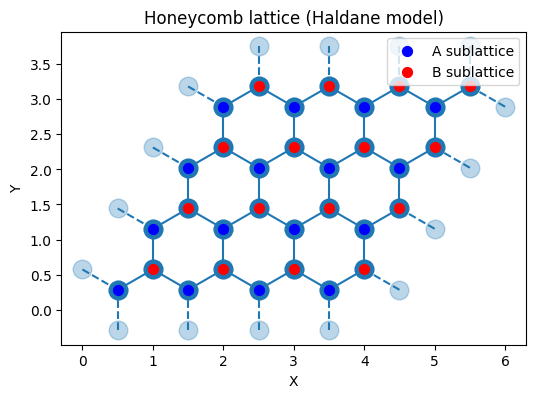

In [27]:
import matplotlib.pyplot as plt
# Visualize the lattice using NetKet built-in drawing
ax = graph.draw(
    distance_order=1,
    draw_text=False,
    draw_basis_vectors=False,
    draw_unit_cell=False,
    node_size=180,
    figsize=(6, 6),
    show=False
)
# Highlight the two honeycomb sublattices (A/B)
coords = graph.basis_coords
positions = graph.positions
a_sites = coords[:, 2] == 0
b_sites = coords[:, 2] == 1
ax.scatter(
    positions[a_sites, 0],
    positions[a_sites, 1],
    s=50,
    c="blue",
    label="A sublattice",
    zorder=5,
)
ax.scatter(
    positions[b_sites, 0],
    positions[b_sites, 1],
    s=50,
    c="red",
    label="B sublattice",
    zorder=5,
)
ax.legend(loc="upper right")
ax.set_title("Honeycomb lattice (Haldane model)")
plt.show()


Automatic SR implementation choice:  QGT


  0%|          | 0/50 [00:00<?, ?it/s]

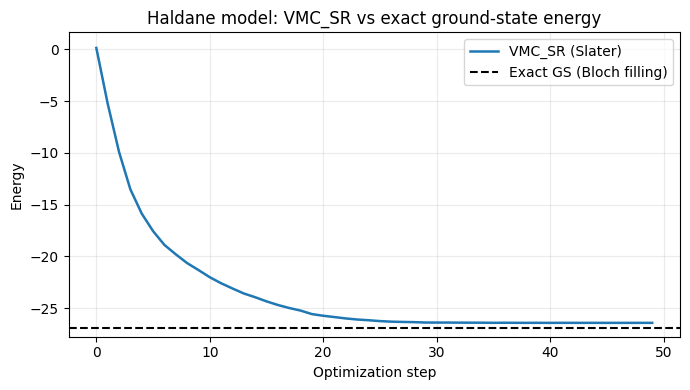

Exact ground-state reference [Bloch-filling (non-interacting)] = -26.9533028639
Final VMC_SR energy (real part) = -26.4314928373
Final error (VMC - reference) = 0.5218100266


In [28]:
import optax
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

def exact_manybody_ground_state_energy(hamiltonian, sparse_threshold=2000):
    # Written with Codex 02-17-26.
    dim = int(hamiltonian.hilbert.n_states)
    if dim > sparse_threshold:
        sparse_h = hamiltonian.to_sparse()
        eigvals = eigsh(
            sparse_h,
            k=1,
            which="SA",
            return_eigenvectors=False,
            tol=1e-10,
        )
        return float(np.real(eigvals[0]))
    dense_h = np.asarray(hamiltonian.to_dense())
    return float(np.linalg.eigvalsh(dense_h)[0].real)

def exact_noninteracting_ground_state_energy_bloch(Lx, Ly, n_fermions, t1, t2, phi, m):
    # Written with Codex 02-17-26.
    b1, b2 = reciprocal_vectors(a1, a2)
    one_body_energies = []
    for n1 in range(Lx):
        for n2 in range(Ly):
            kvec = (n1 / Lx) * b1 + (n2 / Ly) * b2
            one_body_energies.extend(
                eigenvalues_at_k(kvec[0], kvec[1], t1=t1, t2=t2, phi=phi, m=m)
            )
    one_body_energies = np.sort(np.asarray(one_body_energies, dtype=float))
    if n_fermions < 0 or n_fermions > one_body_energies.size:
        raise ValueError("n_fermions is outside the available one-body state count.")
    return float(np.sum(one_body_energies[:n_fermions]))

def exact_reference_ground_state_energy(
    hamiltonian, Lx, Ly, n_fermions, t1, t2, phi, m, V1, sparse_threshold=2000
):
    # Written with Codex 02-17-26.
    if np.isclose(V1, 0.0):
        e_ref = exact_noninteracting_ground_state_energy_bloch(
            Lx=Lx,
            Ly=Ly,
            n_fermions=n_fermions,
            t1=t1,
            t2=t2,
            phi=phi,
            m=m,
        )
        return e_ref, "Exact GS (Bloch filling)", "Bloch-filling (non-interacting)"
    e_ref = exact_manybody_ground_state_energy(hamiltonian, sparse_threshold=sparse_threshold)
    return e_ref, "Exact many-body GS (ED)", "ED (interacting)"

# Slater determinant optimization
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph, n_chains=16, sweep_size=64)
model = LogSlaterDeterminant(hi, param_dtype=complex, rngs=nnx.Rngs(1))
vstate = nk.vqs.MCState(sa, model, n_samples=1024, n_discard_per_chain=16)
opt = nk.optimizer.Sgd(learning_rate=optax.linear_schedule(0.05, 0.005, 100))
gs = nk.driver.VMC_SR(ham, opt, variational_state=vstate, diag_shift=0.01, mode="complex")
log = nk.logging.RuntimeLog()
gs.run(n_iter=50, out=log)
iters = log.data["Energy"].iters
energy_mean = np.asarray(log.data["Energy"]["Mean"])
energy_sigma = np.asarray(log.data["Energy"]["Sigma"])

# Exact reference: Bloch filling for non-interacting V1=0, otherwise ED.
e_ref, e_ref_plot_label, e_ref_method = exact_reference_ground_state_energy(
    hamiltonian=ham,
    Lx=Lx,
    Ly=Ly,
    n_fermions=int(hi.n_fermions),
    t1=t1,
    t2=t2,
    phi=phi,
    m=m,
    V1=V1,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, energy_mean.real, lw=1.8, color="tab:blue", label="VMC_SR (Slater)")
ax.fill_between(
    iters,
    energy_mean.real - energy_sigma,
    energy_mean.real + energy_sigma,
    color="tab:blue",
    alpha=0.2,
    linewidth=0,
)
ax.axhline(e_ref, color="black", ls="--", lw=1.5, label=e_ref_plot_label)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy")
ax.set_title("Haldane model: VMC_SR vs exact ground-state energy")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Exact ground-state reference [{e_ref_method}] = {e_ref:.10f}")
print(f"Final VMC_SR energy (real part) = {energy_mean.real[-1]:.10f}")
print(f"Final error (VMC - reference) = {energy_mean.real[-1] - e_ref:.10f}")


In [29]:
# Fresh post-training sampling from the optimized state (not cached optimizer samples)
obs_n_samples_per_batch = max(4096 * 10, vstate.n_samples)
obs_n_discard_per_chain = max(64, vstate.n_discard_per_chain)
obs_n_resample_batches = 4
vstate.reset()
sample_batches = []

for _ in range(obs_n_resample_batches):
    batch = np.asarray(
        vstate.sample(
            n_samples=obs_n_samples_per_batch,
            n_discard_per_chain=obs_n_discard_per_chain,
        )
    )
    sample_batches.append(batch.reshape(-1, batch.shape[-1]))

samples_obs = np.concatenate(sample_batches, axis=0).astype(float)
n_samples_obs = samples_obs.shape[0]
n_sites_obs = samples_obs.shape[1]
positions_obs = np.asarray(graph.positions, dtype=float)
obs_sampling_run = int(globals().get("obs_sampling_run", 0)) + 1

print(
    f"Post-training sampling run {obs_sampling_run}: {n_samples_obs} total samples "
    f"({obs_n_resample_batches} x {obs_n_samples_per_batch}), "
    f"discard_per_chain={obs_n_discard_per_chain}"
)

Post-training sampling run 3: 163840 total samples (4 x 40960), discard_per_chain=64


Using post-training samples from run 3 (n=163840)


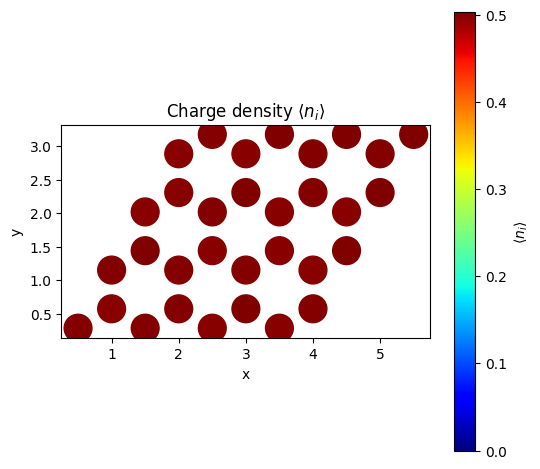

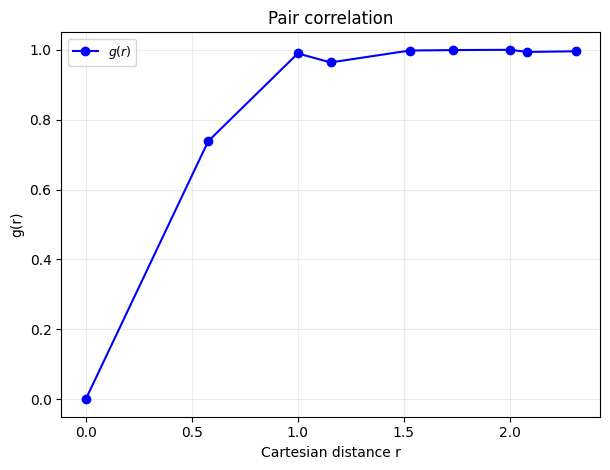

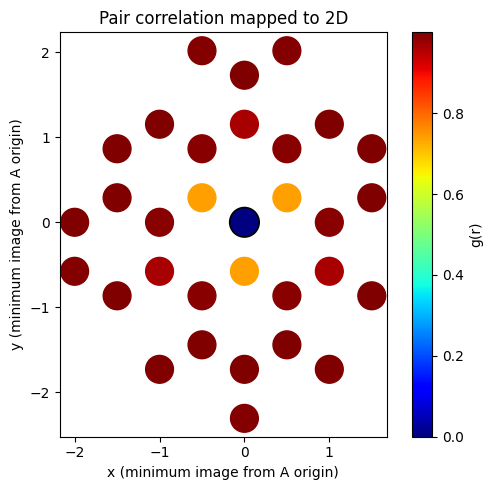

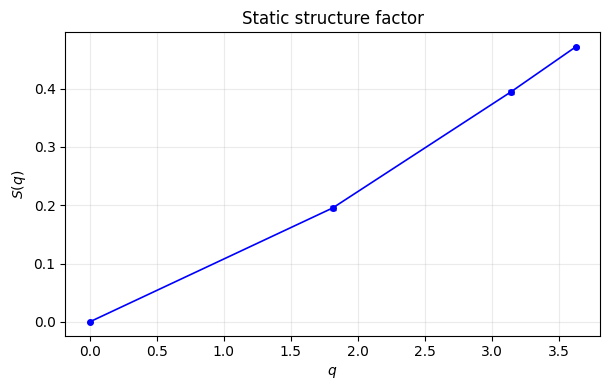

In [30]:
# Post-training observables from MC samples of the optimized wavefunction
# NetKet provides generic expectation tools, but no dedicated built-in helper
# for fermionic pair-correlation / structure-factor post-processing on samples.
import numpy as np
import matplotlib.pyplot as plt
def reciprocal_from_basis(basis_vectors):
    # Written with Codex 02-17-26.
    area = basis_vectors[0, 0] * basis_vectors[1, 1] - basis_vectors[0, 1] * basis_vectors[1, 0]
    b1 = (2.0 * np.pi / area) * np.array([basis_vectors[1, 1], -basis_vectors[1, 0]])
    b2 = (2.0 * np.pi / area) * np.array([-basis_vectors[0, 1], basis_vectors[0, 0]])
    return b1, b2
def fold_to_shortest_k_local(kvec, b1, b2, search_radius=2):
    # Written with Codex 02-17-26.
    basis = np.column_stack((b1, b2))
    coeffs = np.linalg.solve(basis, kvec)
    n0 = np.rint(coeffs).astype(int)
    best_k = None
    best_norm2 = np.inf
    for n1 in range(n0[0] - search_radius, n0[0] + search_radius + 1):
        for n2 in range(n0[1] - search_radius, n0[1] + search_radius + 1):
            krev = kvec - n1 * b1 - n2 * b2
            norm2 = float(np.dot(krev, krev))
            if norm2 < best_norm2:
                best_norm2 = norm2
                best_k = krev
    return best_k


if "samples_obs" not in globals():
    raise RuntimeError("Run the post-training sampling cell before this plotting cell.")
samples = samples_obs
n_samples = int(n_samples_obs)
n_sites = int(n_sites_obs)
positions = positions_obs
print(f"Using post-training samples from run {obs_sampling_run} (n={n_samples})")

# Charge density <n_i>
charge_density = samples.mean(axis=0)

# Pair-correlation matrix G_ij = <n_i n_j>
corr_matrix = (samples.T @ samples) / n_samples
connected_corr = corr_matrix - np.outer(charge_density, charge_density)

# Radially averaged pair-correlation by Cartesian distance
basis_vectors = np.asarray(graph.basis_vectors, dtype=float)
disp = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
pbc = np.asarray(graph.pbc, dtype=bool).reshape(-1)
if pbc.size == 1:
    pbc = np.repeat(pbc, 2)
shift_n1 = (-1, 0, 1) if pbc[0] else (0,)
shift_n2 = (-1, 0, 1) if pbc[1] else (0,)
translations = [
    (n1 * Lx) * basis_vectors[0] + (n2 * Ly) * basis_vectors[1]
    for n1 in shift_n1
    for n2 in shift_n2
]
dist_matrix = np.full((n_sites, n_sites), np.inf, dtype=float)
for t in translations:
    dist_matrix = np.minimum(dist_matrix, np.linalg.norm(disp + t, axis=-1))
offdiag = ~np.eye(n_sites, dtype=bool)
dist_shell = np.round(dist_matrix, 12)
r_values = np.unique(dist_shell[offdiag])
g_r = np.empty(r_values.size, dtype=float)
norm_density = (n_fermions / n_sites) ** 2
for i, r in enumerate(r_values):
    mask = (dist_shell == r) & offdiag
    g_r[i] = corr_matrix[mask].mean().real / norm_density
if r_values.size == 0 or not np.isclose(r_values[0], 0.0):
    r_values_plot = np.concatenate(([0.0], r_values))
    g_r_plot = np.concatenate(([0.0], g_r))
else:
    r_values_plot = r_values.copy()
    g_r_plot = g_r.copy()
    g_r_plot[0] = 0.0

# Expand rotation-averaged g(r) back to 2D using minimum-image site positions
coords = np.asarray(graph.basis_coords)
a_sublattice = np.where(coords[:, 2] == 0)[0]
a_origin = np.where((coords[:, 0] == 0) & (coords[:, 1] == 0) & (coords[:, 2] == 0))[0]
if a_origin.size > 0:
    origin_idx = int(a_origin[0])
elif a_sublattice.size > 0:
    origin_idx = int(a_sublattice[0])
else:
    raise ValueError("Could not find an A-sublattice site for the g(r) origin.")
origin_pos = positions[origin_idx]
rel = positions - origin_pos[np.newaxis, :]
rel_min = np.empty_like(rel)
r_site = np.empty(n_sites, dtype=float)
for i in range(n_sites):
    best_norm2 = np.inf
    best_vec = None
    for t in translations:
        vec = rel[i] + t
        norm2 = float(np.dot(vec, vec))
        if norm2 < best_norm2:
            best_norm2 = norm2
            best_vec = vec
    rel_min[i] = best_vec
    r_site[i] = np.sqrt(best_norm2)
g_lookup = {
    float(np.round(r, 12)): float(g)
    for r, g in zip(r_values_plot, g_r_plot)
}
r_site_shell = np.round(r_site, 12)
g_site = np.array([g_lookup[float(r)] for r in r_site_shell], dtype=float)

# Static structure factor S(q) from raw density on finite-size momentum grid
b1, b2 = reciprocal_from_basis(basis_vectors)
q_list = []
for n1 in range(Lx):
    for n2 in range(Ly):
        q_raw = (n1 / Lx) * b1 + (n2 / Ly) * b2
        q_list.append(fold_to_shortest_k_local(q_raw, b1, b2))
q_list = np.asarray(q_list)
phases = np.exp(-1j * (positions @ q_list.T))
rho_q = samples @ phases
s_q = np.mean(np.abs(rho_q) ** 2, axis=0) / n_fermions
# Plots
fig_charge, ax_charge = plt.subplots(figsize=(5.4, 4.8))
sc0 = ax_charge.scatter(
    positions[:, 0],
    positions[:, 1],
    c=charge_density,
    s=400,
    cmap="jet",
    marker="o",
    clim=(0,np.amax(charge_density))
)
ax_charge.set_title(r"Charge density $\langle n_i \rangle$")
ax_charge.set_xlabel("x")
ax_charge.set_ylabel("y")
ax_charge.set_aspect("equal", "box")
fig_charge.colorbar(sc0, ax=ax_charge, label=r"$\langle n_i \rangle$")
plt.tight_layout()
plt.show()
fig_pair, ax_pair = plt.subplots(figsize=(6.2, 4.8))
ax_pair.plot(r_values_plot, g_r_plot, "o-", label=r"$g(r)$",color="blue")
ax_pair.set_title("Pair correlation")
ax_pair.set_xlabel("Cartesian distance r")
ax_pair.set_ylabel("g(r)")
ax_pair.grid(alpha=0.25)
ax_pair.legend(fontsize=9)
plt.tight_layout()
plt.show()
fig_pair2d, ax_pair2d = plt.subplots(figsize=(5.6, 5.0))
sc_pair2d = ax_pair2d.scatter(
    rel_min[:, 0],
    rel_min[:, 1],
    c=g_site,
    s=400,
    cmap="jet",
    marker="o",
)
ax_pair2d.scatter(
    [0.0],
    [0.0],
    s=450,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
)
ax_pair2d.set_title("Pair correlation mapped to 2D")
ax_pair2d.set_xlabel("x (minimum image from A origin)")
ax_pair2d.set_ylabel("y (minimum image from A origin)")
ax_pair2d.set_aspect("equal", "box")
fig_pair2d.colorbar(sc_pair2d, ax=ax_pair2d, label="g(r)")
plt.tight_layout()
plt.show()

q_abs = np.linalg.norm(q_list, axis=1)
# For plotting, suppress the trivial q=0 density mode (fixed by total particle number).
s_q_plot = s_q.copy()
s_q_plot[q_abs < 1e-12] = 0.0
q_shell = np.round(q_abs, 12)
q_shell_unique = np.unique(q_shell)
s_q_abs = np.empty_like(q_shell_unique)
s_q_abs_err = np.empty_like(q_shell_unique)

for i, qv in enumerate(q_shell_unique):
    vals = s_q_plot.real[q_shell == qv]
    s_q_abs[i] = vals.mean()
    s_q_abs_err[i] = vals.std(ddof=1) / np.sqrt(vals.size) if vals.size > 1 else 0.0
    
fig_abs, ax_abs = plt.subplots(figsize=(6.2, 4.0))
ax_abs.errorbar(q_shell_unique, s_q_abs, yerr=s_q_abs_err, fmt="o-", ms=4, lw=1.2, capsize=2,color="blue")
ax_abs.set_title(r"Static structure factor")
ax_abs.set_xlabel(r"$q$")
ax_abs.set_ylabel(r"$S(q)$")
ax_abs.grid(alpha=0.25)
plt.tight_layout()
plt.show()
